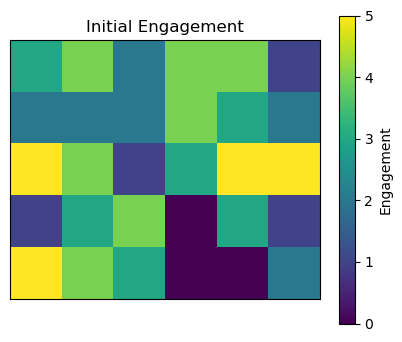

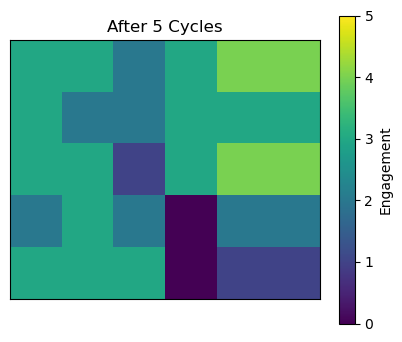

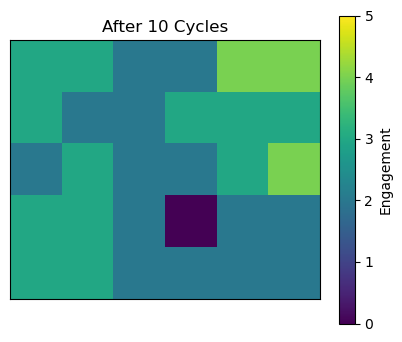

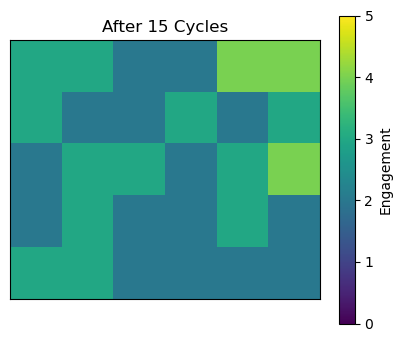

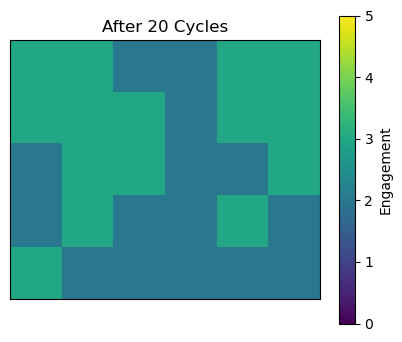

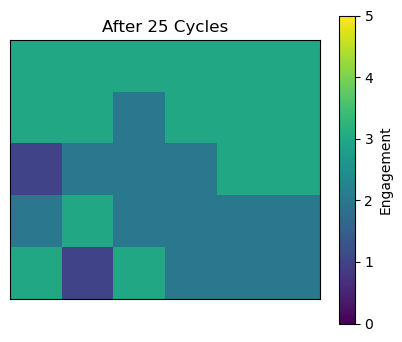

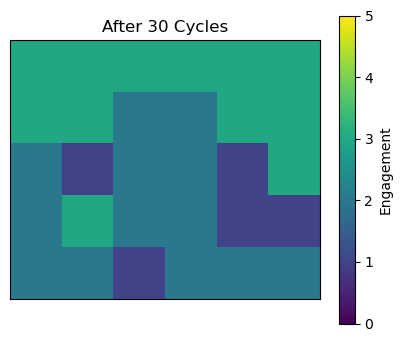

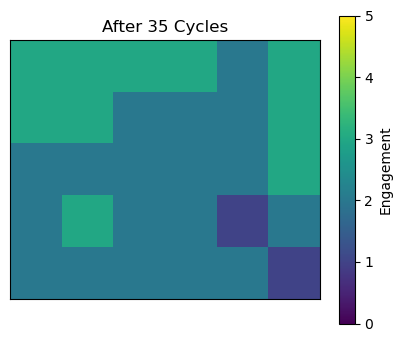

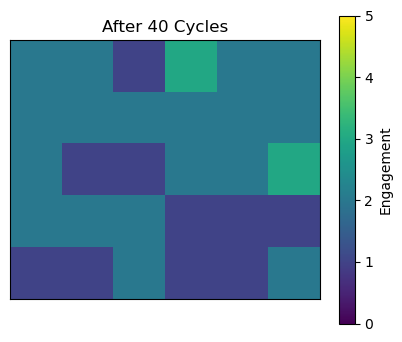

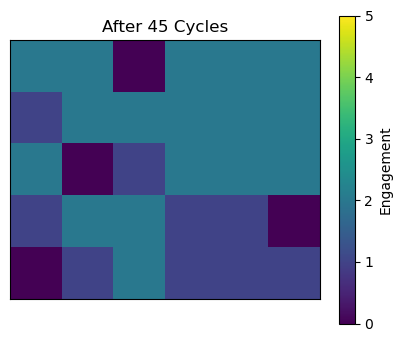

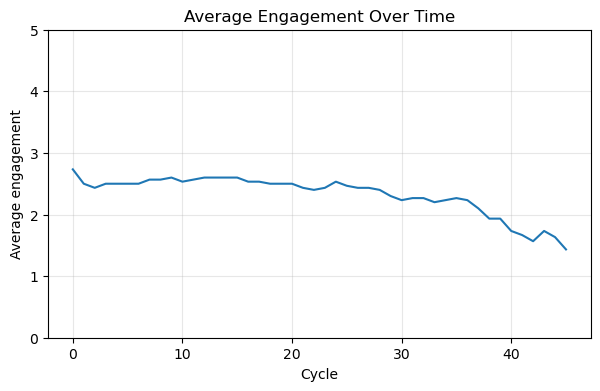

Initial average engagement: 2.733
Final average engagement:   1.433
Net change:                 -1.300


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import random


class ClassroomSimulation:
    """
    Class for student engagement simulation in a classroom.

    Parameters:
        rows, cols (int): dimensions of the classroom
        cycles (int): number of total cycles (minutes)
        engage (int): maximum engagement level
        n_strength (float): neighbor influence strength
        base_fatigue (float): small base fatigue value
        fatigue_growth (float): fatigue acceleration
        seed (int|None): random seed
    """

    # -------------------------------------------------
    def __init__(self, rows, cols, cycles, engage, n_strength,
                 base_fatigue, fatigue_growth, seed=None):

        if seed is not None:
            np.random.seed(seed)

        # Base Parameters
        self.rows = rows
        self.cols = cols
        self.cycles = cycles
        self.engage = engage

        # Neighbor / Time Influence
        self.n_strength = n_strength
        self.base_fatigue = base_fatigue
        self.fatigue_growth = fatigue_growth

        # Define Neighborhood
        self.kernel = np.array([
            [1, 1, 1],
            [1, 0, 1],
            [1, 1, 1]
        ])

        # Create Initial State
        self.E = np.random.randint(
            0, self.engage + 1,
            size=(self.rows, self.cols)
        )

        self.interactive_timer = 0

        # Track engagement stats
        self.avg_history = []  # average engagement per cycle (including t=0 if you add it)

    # -------------------------------------------------
    def plot_state(self, title="Engagement"):
        plt.figure(figsize=(5, 4))
        plt.imshow(self.E, cmap='viridis', vmin=0, vmax=self.engage)
        plt.colorbar(label="Engagement")
        plt.title(title)
        plt.xticks([])
        plt.yticks([])
        plt.show()

    # -------------------------------------------------
    def plot_average_engagement(self, title="Average Engagement Over Time"):
        if len(self.avg_history) == 0:
            print("No history to plot. Run the simulation first.")
            return

        plt.figure(figsize=(7, 4))
        plt.plot(range(len(self.avg_history)), self.avg_history)
        plt.title(title)
        plt.xlabel("Cycle")
        plt.ylabel("Average engagement")
        plt.ylim(0, self.engage)
        plt.grid(True, alpha=0.3)
        plt.show()

        # Print summary
        print(f"Initial average engagement: {self.avg_history[0]:.3f}")
        print(f"Final average engagement:   {self.avg_history[-1]:.3f}")
        print(f"Net change:                 {self.avg_history[-1] - self.avg_history[0]:.3f}")

    # -------------------------------------------------
    def baseline_update(self, t):
        neighbors_sum = convolve2d(
            self.E, self.kernel,
            mode='same', boundary='fill', fillvalue=0
        )
        neighbor_count = convolve2d(
            np.ones_like(self.E),
            self.kernel,
            mode='same', boundary='fill', fillvalue=0
        )
        neighbor_avg = neighbors_sum / neighbor_count

        E_new = self.E.copy()

        # --- Neighbor influence (probabilistic) ---
        multiplier = 2 if self.interactive_timer > 0 else 1
        k = self.n_strength * multiplier

        diff = neighbor_avg - self.E

        prob_increase = np.clip(k * (diff / self.engage), 0, 1)
        prob_decrease = np.clip(k * (-diff / self.engage), 0, 1)

        rand_matrix = np.random.rand(self.rows, self.cols)

        E_new += (rand_matrix < prob_increase).astype(int)
        E_new -= (rand_matrix < prob_decrease).astype(int)

        # --- Time-based fatigue ---
        fatigue_prob = (
            self.base_fatigue +
            self.fatigue_growth * (t / self.cycles) ** 2
        )

        fatigue_rand = np.random.rand(self.rows, self.cols)
        fatigue = (fatigue_rand < fatigue_prob).astype(int)
        E_new -= fatigue

        self.E = np.clip(E_new, 0, self.engage).astype(int)

    # -------------------------------------------------
    def teacher_actions(self, action_type, duration=0):
        match action_type:
            # 1: Question to everyone (+1 to low engagement people)
            case 1:
                boost = (self.E <= 2).astype(int)
                self.E = np.clip(self.E + boost, 0, self.engage)

            # 2: Question to region (+2 to region)
            case 2:
                r_start = random.randint(0, self.rows - 2)
                c_start = random.randint(0, self.cols - 2)
                self.E[r_start:r_start + 2, c_start:c_start + 2] += 2
                self.E = np.clip(self.E, 0, self.engage)

            # 3: Interactive job (for N cycles doubling neighbour effect)
            case 3:
                self.interactive_timer = int(duration)

            # 4: Helping a behind student (+ to them, - to others)
            case 4:
                idx = np.unravel_index(np.argmin(self.E), self.E.shape)
                self.E[idx] += 2
                self.E -= 1
                self.E[idx] += 1
                self.E = np.clip(self.E, 0, self.engage)

            # 5: Humor/jokes (+1 to everyone)
            case 5:
                self.E = np.clip(self.E + 1, 0, self.engage)

            # 6: Games/challenges (interactivity, +1 to everyone)
            case 6:
                self.E = np.clip(self.E + 1, 0, self.engage)
                self.interactive_timer = int(duration)

            case _:
                # Unknown action id -> do nothing
                pass

    # -------------------------------------------------
    def _apply_schedule_actions(self, t, schedule):
        """
        schedule format (list of dicts):
        [
          {"time": 5, "action": 1},
          {"time": 10, "action": 2},
          {"time": 15, "action": 3, "duration": 5},
          ...
        ]
        Times are interpreted as cycle indices (0-based) by default.
        If you'd rather use "minute numbers" 1..cycles, pass those and set schedule_is_1_based=True in run().
        """
        if not schedule:
            return

        # Apply all events scheduled for this timestep
        for event in schedule:
            if event.get("time") == t:
                action = int(event.get("action"))
                duration = event.get("duration", 0)
                self.teacher_actions(action, duration=duration)

    # -------------------------------------------------
    def run(self, show_every=5, schedule=None, schedule_is_1_based=True, random_actions=False):
        """
        Args:
            show_every: show heatmap every N cycles
            schedule: list of scheduled teacher action dicts (see _apply_schedule_actions)
            schedule_is_1_based: if True, schedule 'time' values are treated as 1..cycles (we convert to 0-based)
            random_actions: if True, also apply a random teacher action every 5 cycles (in addition to schedule)
        """

        # Convert schedule to 0-based times if needed
        schedule_0 = []
        if schedule:
            if schedule_is_1_based:
                for e in schedule:
                    e2 = dict(e)
                    e2["time"] = int(e2["time"]) - 1
                    schedule_0.append(e2)
            else:
                schedule_0 = schedule

        # Record initial average
        self.avg_history = [float(np.mean(self.E))]

        self.plot_state("Initial Engagement")

        for t in range(self.cycles):

            # Scheduled teacher actions (separate operator)
            self._apply_schedule_actions(t, schedule_0)

            # Optional random teacher actions
            if random_actions and (t + 1) % 5 == 0:
                self.teacher_actions(random.randint(1, 5))  # 1..5 only

            # Neighbor + time influence
            self.baseline_update(t)

            if self.interactive_timer > 0:
                self.interactive_timer -= 1

            # Record average after update
            self.avg_history.append(float(np.mean(self.E)))

            if (t + 1) % show_every == 0:
                self.plot_state(f"After {t + 1} Cycles")

        # Plot average engagement over time at end
        self.plot_average_engagement()

sim = ClassroomSimulation(
    rows=5,
    cols=6,
    cycles=45,
    engage=5,
    n_strength=0.7,
    base_fatigue=0.01,
    fatigue_growth=0.06,
    seed=42
)

schedule = [
    {"time": 5,  "action": 1},               # question to everyone
    {"time": 10, "action": 2},               # question to region
    {"time": 15, "action": 3, "duration": 5},# interactive job 5 cycles
    {"time": 25, "action": 4},               # help behind student
    {"time": 35, "action": 5},               # humor
]
schedule = []

sim.run(show_every=5, schedule=schedule)